# PlantVillage: Exploratory Data Analysis
**Project:** [smart-irrigation](https://github.com/Shubhveer/smart-irrigation) · **Feature:** crop disease detection from leaf photos

**Dataset:** PlantVillage, 54,305 colour leaf images in 38 classes (14 crops).
Kaggle copy: `abdallahalidev/plantvillage-dataset`.

**How this notebook was run.** Kaggle was not reachable from the environment that executed it, so the data came from the original
PlantVillage repository on GitHub (`spMohanty/PlantVillage-Dataset`, `raw/color`), which has the same 54,305 colour images.
- **File-level analysis** (class counts, crops, duplicates) uses all 54,305 files via `plantvillage_manifest.csv`
  (file list plus the content hash of every image).
- **Pixel-level analysis** (size, colour, background, shortcut test) uses a stratified sample of **60 images per class (2,280 images)**.

To re-run on the full Kaggle data, remove the `PV_COLOR_DIR` environment variable. The notebook then downloads the dataset with `kagglehub`
and works on every image.

## 0. Setup and load data

In [1]:
import os, hashlib, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
SEED = 42

MANIFEST = Path("plantvillage_manifest.csv")
DATA_DIR = os.environ.get("PV_COLOR_DIR")          # folder that contains the 38 class folders
if DATA_DIR is None:                                # default: download full dataset from Kaggle
    import kagglehub
    root = Path(kagglehub.dataset_download("abdallahalidev/plantvillage-dataset"))
    DATA_DIR = next(p for p in root.rglob("color") if p.is_dir())
DATA_DIR = Path(DATA_DIR)
print("Image folder:", DATA_DIR)

Image folder: /home/claude/pv_sample/color


In [2]:
def scan_folder():
    rows = [(d.name, f.name) for d in sorted(DATA_DIR.iterdir()) if d.is_dir()
            for f in d.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    d = pd.DataFrame(rows, columns=["label", "filename"])
    print(f"Hashing {len(d):,} files (about a minute)...")
    d["content_hash"] = [hashlib.md5(open(DATA_DIR / l / f, "rb").read()).hexdigest()
                         for l, f in zip(d.label, d.filename)]
    return d

def add_columns(d):
    parts = d.label.str.partition("___")
    d["crop"] = parts[0].str.replace("_", " ")
    d["condition"] = parts[2].str.replace("_", " ").str.strip()
    d["healthy"] = d.condition.str.lower().eq("healthy")
    d["path"] = [DATA_DIR / l / f for l, f in zip(d.label, d.filename)]
    d["on_disk"] = [p.exists() for p in d.path]
    return d

if MANIFEST.exists():
    df = add_columns(pd.read_csv(MANIFEST).rename(columns={"git_blob_sha": "content_hash"}))
else:
    df = add_columns(scan_folder())
if df.on_disk.sum() == 0:      # manifest file names do not match this copy of the dataset
    print("Manifest does not match the images in DATA_DIR -> scanning the folder instead")
    df = add_columns(scan_folder())

print(f"Total images : {len(df):,}")
print(f"Classes      : {df.label.nunique()}")
print(f"Crops        : {df.crop.nunique()}")
print(f"Healthy imgs : {df.healthy.sum():,} ({df.healthy.mean():.1%})   Diseased: {(~df.healthy).sum():,}")
print(f"Images on disk for pixel analysis: {df.on_disk.sum():,}")
df.drop(columns="path").head()

Total images : 54,305
Classes      : 38
Crops        : 14
Healthy imgs : 15,084 (27.8%)   Diseased: 39,221
Images on disk for pixel analysis: 2,280


,label,filename,content_hash,crop,condition,healthy,on_disk
0,Apple___Apple_scab,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,89b26cf853e056f9ead1d8b8628f67b32fa89716,Apple,Apple scab,False,False
1,Apple___Apple_scab,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,35f5772a06ba92c60c280ffef0bebd6ce7473389,Apple,Apple scab,False,False
2,Apple___Apple_scab,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,6f06399d7e36a2ccb7713041a3d27b5858ba87ec,Apple,Apple scab,False,True
3,Apple___Apple_scab,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,de0ebf98fe44ae8610291a2dbbb3f8b64f3dc731,Apple,Apple scab,False,False
4,Apple___Apple_scab,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,6a9b91c2cdc8c941cee37d11cde1d088e8de4ba3,Apple,Apple scab,False,False


## 1. Class distribution and imbalance

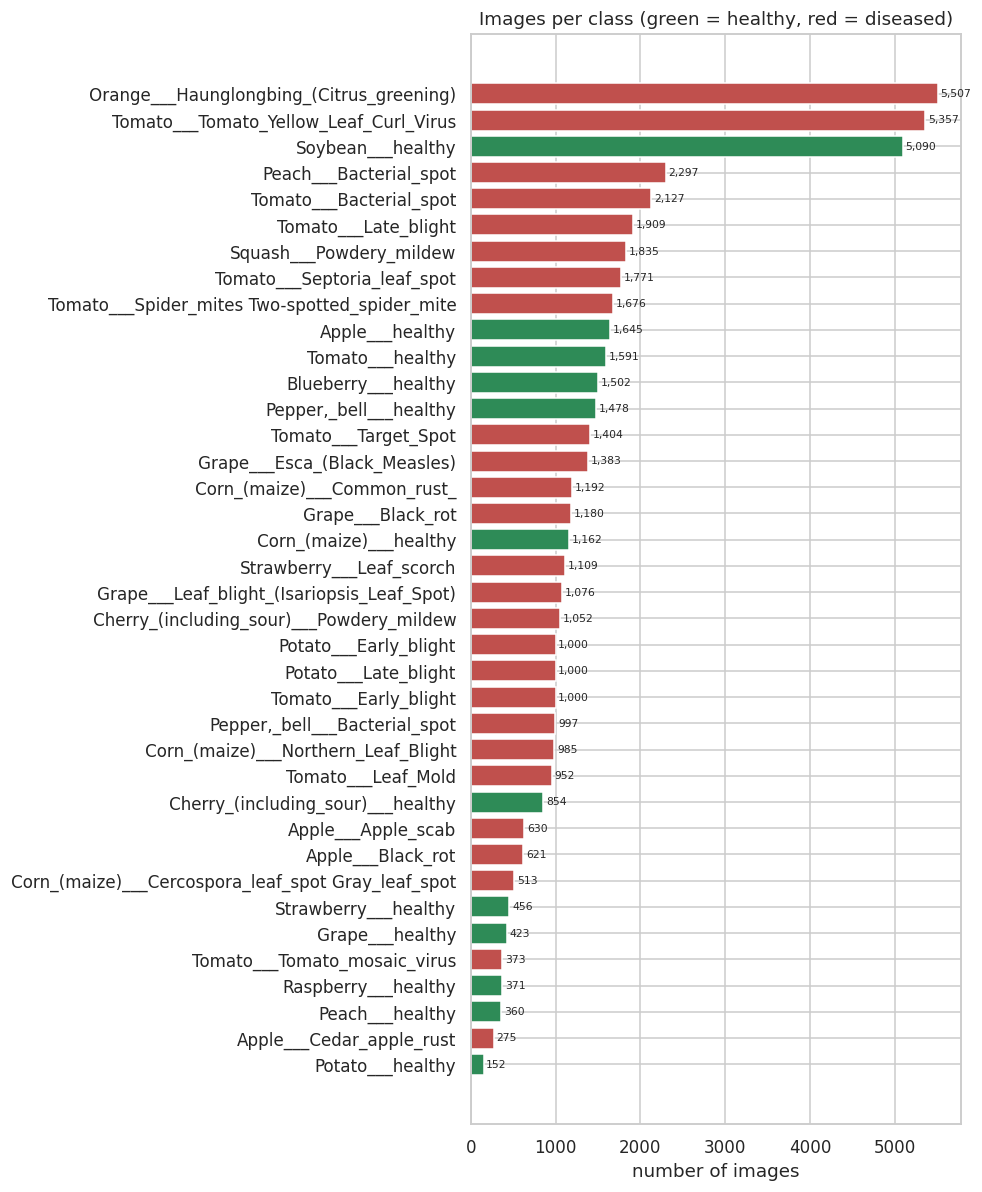

Largest class : Orange___Haunglongbing_(Citrus_greening) = 5,507
Smallest class: Potato___healthy = 152
Imbalance ratio (max/min): 36.2x
Median class size: 1,092
Classes with < 1,000 images: 14 of 38


In [3]:
counts = df.label.value_counts()
fig, ax = plt.subplots(figsize=(9, 11))
colors = ["#2e8b57" if "healthy" in l.lower() else "#c0504d" for l in counts.index]
ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
ax.set_title("Images per class (green = healthy, red = diseased)")
ax.set_xlabel("number of images")
for i, v in enumerate(counts.values[::-1]): ax.text(v + 30, i, f"{v:,}", va="center", fontsize=7)
plt.tight_layout(); plt.show()

print(f"Largest class : {counts.index[0]} = {counts.iloc[0]:,}")
print(f"Smallest class: {counts.index[-1]} = {counts.iloc[-1]:,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")
print(f"Median class size: {int(counts.median()):,}")
print(f"Classes with < 1,000 images: {(counts < 1000).sum()} of {len(counts)}")

## 2. Crops: which have healthy vs diseased examples?

,images,classes,healthy,diseased,has_healthy_class,has_disease_class
crop,,,,,,
Tomato,18160,10,1591,16569,True,True
Orange,5507,1,0,5507,False,True
Soybean,5090,1,5090,0,True,False
Grape,4062,4,423,3639,True,True
Corn (maize),3852,4,1162,2690,True,True
Apple,3171,4,1645,1526,True,True
Peach,2657,2,360,2297,True,True
"Pepper, bell",2475,2,1478,997,True,True
Potato,2152,3,152,2000,True,True


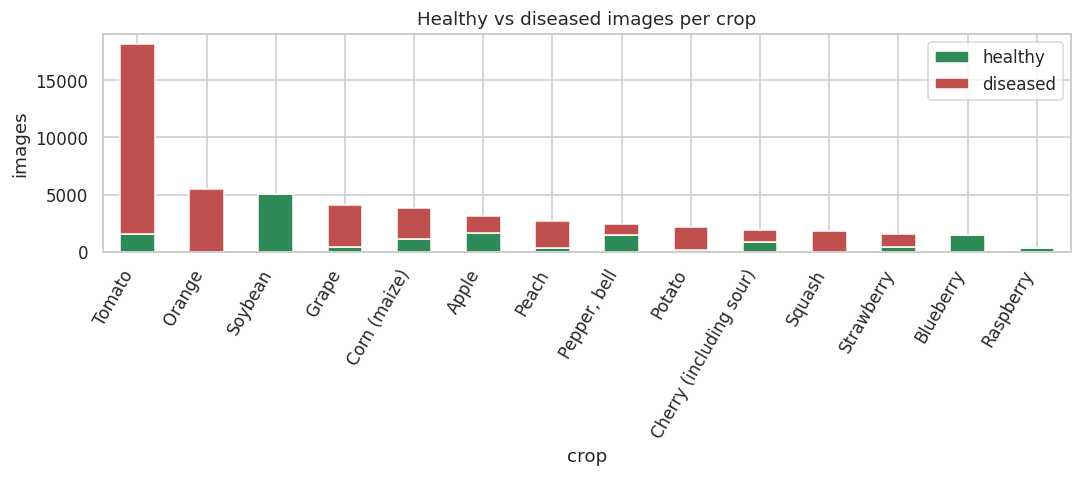

Crops with ONLY healthy images : ['Soybean', 'Blueberry', 'Raspberry']
Crops with NO healthy images   : ['Orange', 'Squash']


In [4]:
crop_tab = (df.groupby("crop")
              .agg(images=("label", "size"), classes=("label", "nunique"),
                   healthy=("healthy", "sum"))
              .assign(diseased=lambda t: t.images - t.healthy,
                      has_healthy_class=lambda t: t.healthy > 0,
                      has_disease_class=lambda t: t.images - t.healthy > 0)
              .sort_values("images", ascending=False))
display(crop_tab)

crop_tab[["healthy", "diseased"]].plot(kind="bar", stacked=True, figsize=(10, 4.5),
                                       color=["#2e8b57", "#c0504d"])
plt.title("Healthy vs diseased images per crop"); plt.ylabel("images"); plt.xticks(rotation=60, ha="right")
plt.tight_layout(); plt.show()

print("Crops with ONLY healthy images :", list(crop_tab.index[~crop_tab.has_disease_class]))
print("Crops with NO healthy images   :", list(crop_tab.index[~crop_tab.has_healthy_class]))

## 3. Disease type and pest coverage
The project feature is "pest detection", so it matters what the labels actually are. Each class is grouped into a coarse category by name
(simplified from standard plant-pathology knowledge; *Late blight* is an oomycete but is grouped with fungal diseases here).

,images,share_%,classes
category,,,
Bacterial,10928,20.12,4
Fungal / oomycete,20887,38.46,19
Healthy,15084,27.78,12
Pest (mite),1676,3.09,1
Viral,5730,10.55,2


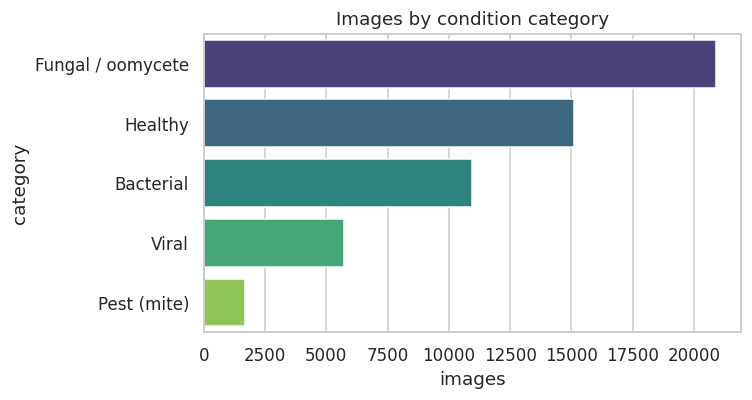

Pest classes: 1 -> ['Tomato___Spider_mites Two-spotted_spider_mite']
Pest images : 1,676 = 3.09% of the dataset


In [5]:
def category(cond):
    c = cond.lower()
    if c == "healthy": return "Healthy"
    if "virus" in c: return "Viral"
    if "spider mite" in c: return "Pest (mite)"
    if "bacterial" in c or "haunglongbing" in c: return "Bacterial"
    return "Fungal / oomycete"

df["category"] = df.condition.map(category)
cat = df.category.value_counts()
cat_classes = df.groupby("category").label.nunique()
summary = pd.DataFrame({"images": cat, "share_%": (cat / len(df) * 100).round(2), "classes": cat_classes})
display(summary)

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(x=cat.values, y=cat.index, palette="viridis", ax=ax)
ax.set_title("Images by condition category"); ax.set_xlabel("images"); plt.tight_layout(); plt.show()

pest = df[df.category == "Pest (mite)"]
print(f"Pest classes: {pest.label.nunique()} -> {pest.label.unique().tolist()}")
print(f"Pest images : {len(pest):,} = {len(pest) / len(df):.2%} of the dataset")

## 4. Duplicates and leakage risk (full dataset)
Identical image content is detected with a content hash (identical hash means identical bytes). Duplicates that land in both train and
validation/test sets inflate accuracy, and the same image under two different labels is a labelling conflict.

In [6]:
dup_rows = df.duplicated("content_hash", keep=False)
extra = df.duplicated("content_hash", keep="first").sum()
print(f"Images whose content appears more than once : {dup_rows.sum():,}")
print(f"Redundant extra copies (removable)           : {extra:,}  ({extra / len(df):.3%})")

g = df.groupby("content_hash").agg(copies=("label", "size"), n_labels=("label", "nunique"))
conflict = g[g.n_labels > 1]
print(f"Identical images carrying DIFFERENT labels   : {len(conflict)}")

display(df[dup_rows].label.value_counts().to_frame("rows_in_duplicate_groups"))

Images whose content appears more than once : 42
Redundant extra copies (removable)           : 21  (0.039%)
Identical images carrying DIFFERENT labels   : 0


,rows_in_duplicate_groups
label,
Tomato___Late_blight,16
Apple___healthy,14
Tomato___healthy,12


In [7]:
# Name check: the same ORIGINAL file name appears in many rows. Is that real duplication?
df["orig_name"] = (df.filename.str.split("___").str[-1]
                     .str.replace(r"\.\w+$", "", regex=True).str.lower())
g2 = df.groupby("orig_name").agg(rows=("label", "size"), n_labels=("label", "nunique"),
                                 n_hash=("content_hash", "nunique"))
cross = g2[g2.n_labels > 1]
same = g2[(g2.n_labels == 1) & (g2.rows > 1)]
print(f"Original names shared by rows in DIFFERENT classes: {len(cross):,}")
print(f"  ...of which every row has different image content: {(cross.n_hash == cross.rows).mean():.1%}")
print(f"Original names repeated inside ONE class          : {len(same):,}")
print(f"  ...of which are byte-identical copies           : {(same.n_hash == 1).mean():.1%}")
print()
print("-> Matching file names across classes (e.g. 'RS_HL 0313' in two different crops) are NOT duplicates:")
print("   they are camera counters reused across crops. Never de-duplicate by file name, use the content hash.")

Original names shared by rows in DIFFERENT classes: 2,171
  ...of which every row has different image content: 99.7%
Original names repeated inside ONE class          : 14
  ...of which are byte-identical copies           : 100.0%

-> Matching file names across classes (e.g. 'RS_HL 0313' in two different crops) are NOT duplicates:
   they are camera counters reused across crops. Never de-duplicate by file name, use the content hash.


## 5. Image properties (stratified sample of up to 60 images per class)
Checks image size, format, brightness, colour and how plain the background is.

In [8]:
on = df[df.on_disk].sample(frac=1, random_state=SEED)
sample = on.groupby("label").head(60).reset_index(drop=True)
print(f"Sample: {len(sample):,} images, {sample.label.nunique()} classes")

def img_feats(p):
    with Image.open(p) as im:
        w, h, mode, fmt = *im.size, im.mode, im.format
        rgb_im = im.convert("RGB")
        rgb = np.asarray(rgb_im, dtype=np.float32)
        hsv = np.asarray(rgb_im.convert("HSV"), dtype=np.float32)
    gray = rgb.mean(2)
    d = dict(width=w, height=h, mode=mode, fmt=fmt, bytes=os.path.getsize(p),
             brightness=gray.mean(), contrast=gray.std(),
             r=rgb[..., 0].mean(), g=rgb[..., 1].mean(), b=rgb[..., 2].mean(),
             green_frac=((hsv[..., 0] >= 25) & (hsv[..., 0] <= 95) & (hsv[..., 1] > 60)).mean(),
             border_std=np.concatenate([gray[:8].ravel(), gray[-8:].ravel(),
                                        gray[:, :8].ravel(), gray[:, -8:].ravel()]).std())
    k = 16
    for i, c in enumerate([rgb[:k, :k], rgb[:k, -k:], rgb[-k:, :k], rgb[-k:, -k:]]):
        for j, ch in enumerate("rgb"): d[f"corner{i}_{ch}"] = c[..., j].mean()
    return d

feat = pd.concat([sample[["label", "crop", "category"]],
                  pd.DataFrame([img_feats(p) for p in sample.path])], axis=1)
print("Image sizes (w x h):"); print(feat.groupby(["width", "height"]).size().to_string())
print("Colour modes:", feat["mode"].value_counts().to_dict(), "| formats:", feat.fmt.value_counts().to_dict())
print(f"All {len(feat):,} sample images opened without error")
print(f"File size: median {feat.bytes.median() / 1024:.0f} KB, max {feat.bytes.max() / 1024:.0f} KB")

Sample: 2,280 images, 38 classes


Image sizes (w x h):
width  height
256    256       2280
Colour modes: {'RGB': 2280} | formats: {'JPEG': 2280}
All 2,280 sample images opened without error
File size: median 16 KB, max 27 KB


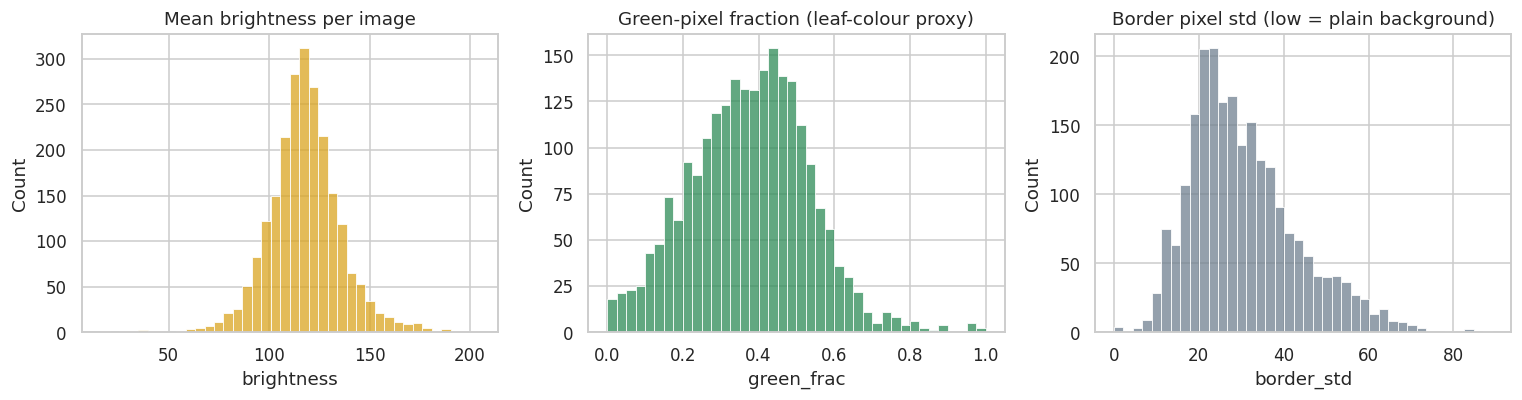

Border-std quantiles (grey levels): {0.1: 16.4, 0.5: 28.2, 0.9: 48.9}


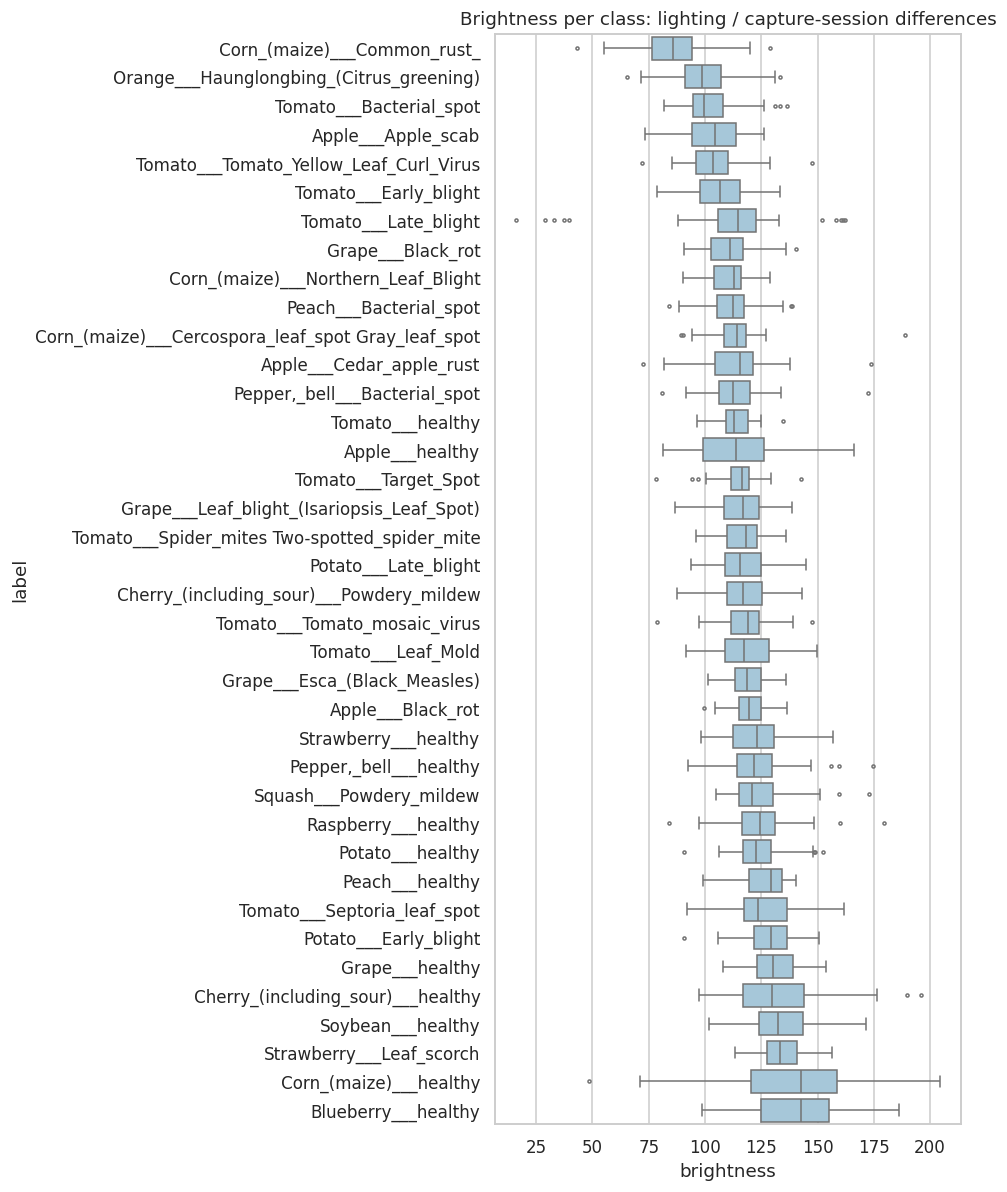

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
sns.histplot(feat.brightness, bins=40, ax=ax[0], color="goldenrod"); ax[0].set_title("Mean brightness per image")
sns.histplot(feat.green_frac, bins=40, ax=ax[1], color="seagreen"); ax[1].set_title("Green-pixel fraction (leaf-colour proxy)")
sns.histplot(feat.border_std, bins=40, ax=ax[2], color="slategray"); ax[2].set_title("Border pixel std (low = plain background)")
plt.tight_layout(); plt.show()

print("Border-std quantiles (grey levels):", feat.border_std.quantile([.1, .5, .9]).round(1).to_dict())

order = feat.groupby("label").brightness.mean().sort_values().index
plt.figure(figsize=(9, 11))
sns.boxplot(data=feat, y="label", x="brightness", order=order, color="#9ecae1", fliersize=2)
plt.title("Brightness per class: lighting / capture-session differences"); plt.tight_layout(); plt.show()

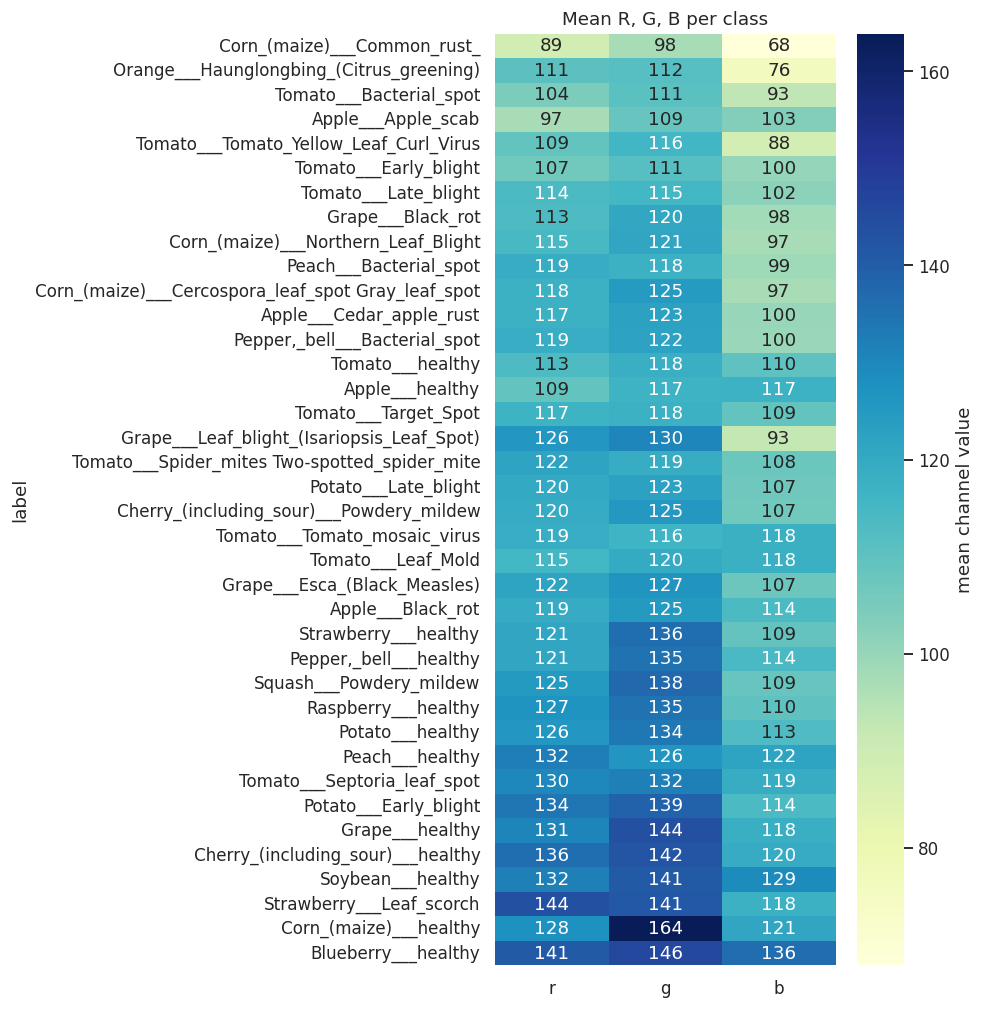

Brightest classes: ['Blueberry___healthy', 'Corn_(maize)___healthy', 'Strawberry___Leaf_scorch']
Darkest classes  : ['Corn_(maize)___Common_rust_', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Bacterial_spot']


In [10]:
rgb_by_class = feat.groupby("label")[["r", "g", "b"]].mean().loc[order]
plt.figure(figsize=(5, 11))
sns.heatmap(rgb_by_class, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "mean channel value"})
plt.title("Mean R, G, B per class"); plt.tight_layout(); plt.show()
print("Brightest classes:", order[-3:].tolist()[::-1])
print("Darkest classes  :", order[:3].tolist())

## 6. Shortcut-learning test: can the label be guessed without looking at the leaf?
PlantVillage photos were taken in controlled sessions, so background colour and lighting can differ between classes. If a simple model that sees
only **four 16x16 corner patches** (background, no leaf) or only **global colour statistics** predicts the class far above chance, a deep model can
cheat the same way and will look better in testing than it will be on real farm photos.

Random guessing                                         accuracy   2.6% +/- 0.0%
Global colour stats (R,G,B, brightness, contrast)       accuracy  30.4% +/- 1.8%
Background only (4 corner patches, 12 values)           accuracy  32.2% +/- 2.8%


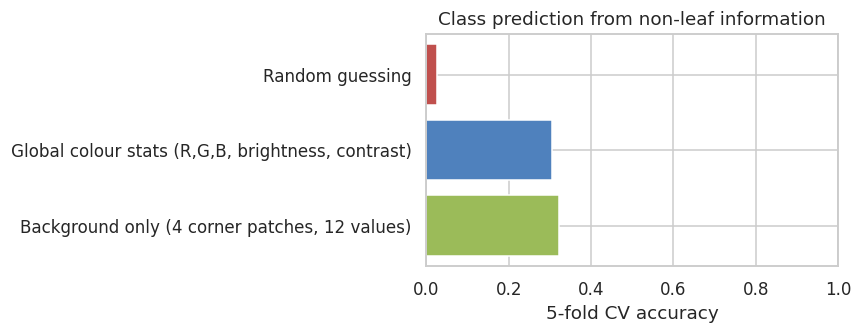


The background corners alone are 12x better than random guessing.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

y = feat.label
corner_cols = [c for c in feat.columns if c.startswith("corner")]
sets = {"Global colour stats (R,G,B, brightness, contrast)": ["r", "g", "b", "brightness", "contrast"],
        "Background only (4 corner patches, 12 values)": corner_cols}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
chance = 1 / y.nunique()
res = {"Random guessing": (chance, 0.0)}
for name, cols in sets.items():
    s = cross_val_score(RandomForestClassifier(300, n_jobs=-1, random_state=SEED), feat[cols], y, cv=cv)
    res[name] = (s.mean(), s.std())

for k, (m, s) in res.items(): print(f"{k:55s} accuracy {m:6.1%} +/- {s:.1%}")
plt.figure(figsize=(8, 3.2))
plt.barh(list(res)[::-1], [v[0] for v in res.values()][::-1], color=["#c0504d", "#4f81bd", "#9bbb59"][::-1])
plt.xlabel("5-fold CV accuracy"); plt.title("Class prediction from non-leaf information"); plt.xlim(0, 1)
plt.tight_layout(); plt.show()
print(f"\nThe background corners alone are {res[list(res)[2]][0] / chance:.0f}x better than random guessing.")

## 7. Visual check

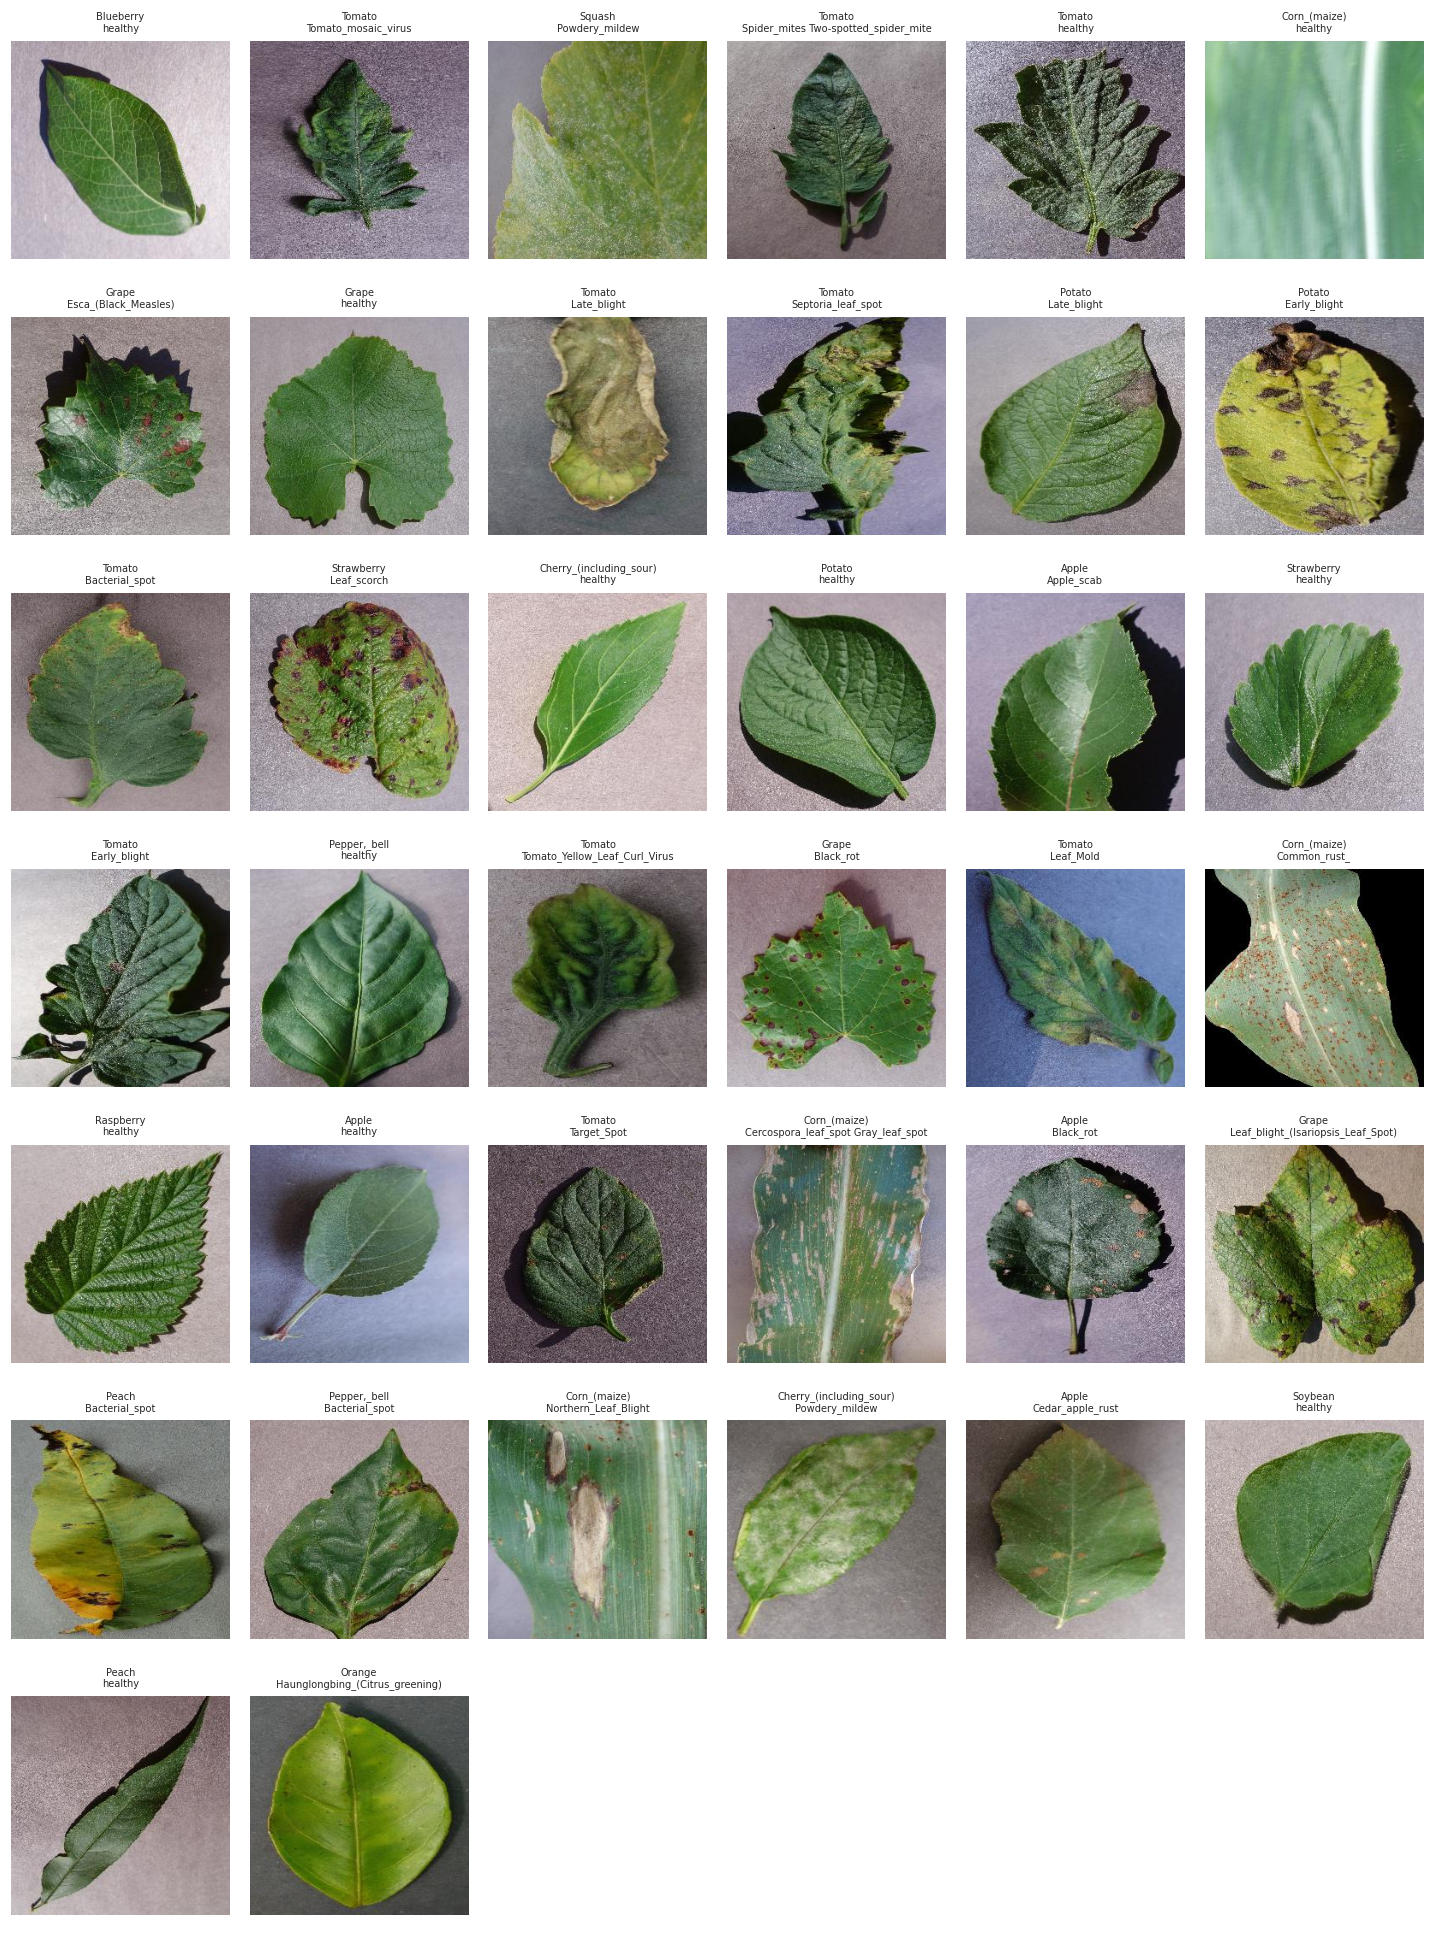

In [12]:
def grid(paths, titles, ncols, cell=2.2, fs=6.5):
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * cell, nrows * (cell + .35)))
    for ax in np.ravel(axes): ax.axis("off")
    for ax, p, t in zip(np.ravel(axes), paths, titles):
        ax.imshow(Image.open(p)); ax.set_title(t, fontsize=fs)
    plt.tight_layout(); plt.show()

one = sample.groupby("label").head(1)
grid(one.path, [l.replace("___", "\n") for l in one.label], ncols=6)

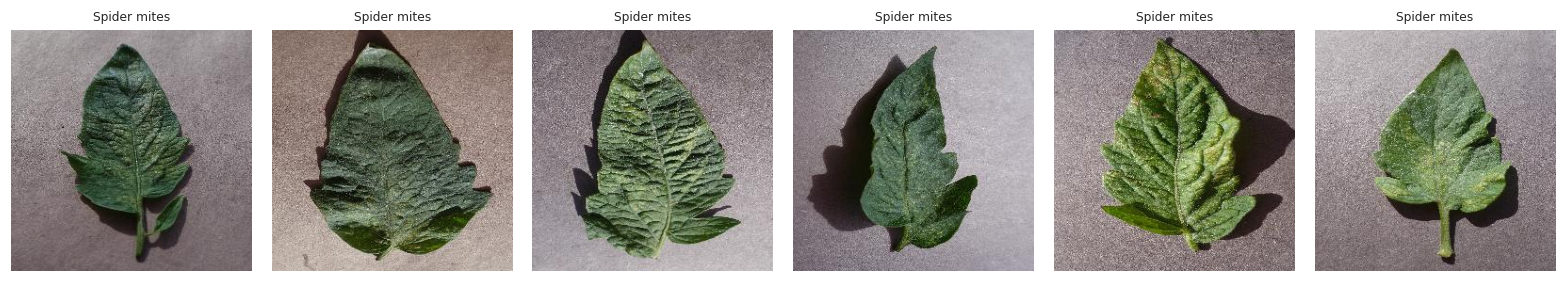

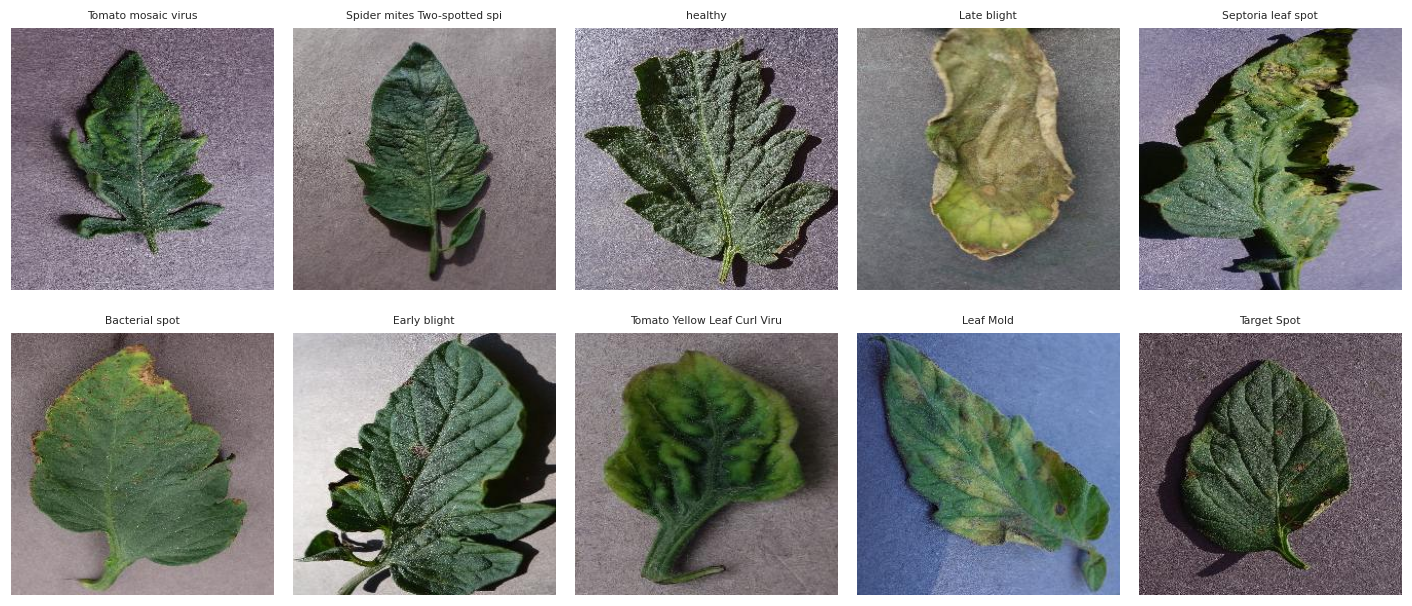

In [13]:
mite = sample[sample.category == "Pest (mite)"].head(6)
grid(mite.path, ["Spider mites"] * len(mite), ncols=6, cell=2.4, fs=8)
tom = sample[sample.crop == "Tomato"].groupby("label").head(1)
grid(tom.path, [l.split("___")[1].replace("_", " ")[:28] for l in tom.label], ncols=5, cell=2.6, fs=7)

## 8. Splits and class weights for training
Plan used: remove identical-content copies (and any image carrying two labels), then split 80/10/10 stratified by class.
This removes **exact** duplicates only. PlantVillage also contains several photos of the same leaf, which cannot be detected from file names
and can still leak between splits, so test on your own farm photos as well.

In [14]:
from sklearn.model_selection import train_test_split

clean = df[~df.content_hash.isin(conflict.index)].drop_duplicates("content_hash")
print(f"After removing duplicates/conflicts: {len(clean):,} images (dropped {len(df) - len(clean):,})")

tr, tmp = train_test_split(clean, test_size=0.2, stratify=clean.label, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.5, stratify=tmp.label, random_state=SEED)
splits = pd.concat([tr.assign(split="train"), va.assign(split="val"), te.assign(split="test")])
print(splits.split.value_counts().to_string())
print("Smallest class per split:", splits.groupby("split").label.apply(lambda s: s.value_counts().min()).to_dict())

splits[["label", "filename", "content_hash", "split"]].to_csv("plantvillage_splits.csv", index=False)
print("Saved plantvillage_splits.csv")

tc = tr.label.value_counts()
w = (len(tr) / (tc.size * tc)).round(2).sort_values(ascending=False)
print("\nClass weights (inverse frequency), highest 5 / lowest 3:")
print(pd.concat([w.head(5), w.tail(3)]).to_string())

After removing duplicates/conflicts: 54,284 images (dropped 21)
split
train    43427
test      5429
val       5428
Smallest class per split: {'test': 15, 'train': 122, 'val': 15}
Saved plantvillage_splits.csv

Class weights (inverse frequency), highest 5 / lowest 3:
label
Potato___healthy                            9.37
Apple___Cedar_apple_rust                    5.19
Peach___healthy                             3.97
Raspberry___healthy                         3.85
Tomato___Tomato_mosaic_virus                3.83
Soybean___healthy                           0.28
Tomato___Tomato_Yellow_Leaf_Curl_Virus      0.27
Orange___Haunglongbing_(Citrus_greening)    0.26


## 9. Key findings

**What the data shows (numbers from the cells above)**

1. **Strong class imbalance.** 54,305 images, 38 classes, 14 crops. The largest class (Orange, citrus greening) has 5,507 images and the smallest
   (Potato, healthy) has 152, a **36x** gap. 14 of 38 classes have fewer than 1,000 images.
   *Use class weights and report macro-F1 and per-class recall, not plain accuracy.*
2. **Crop identity can stand in for health.** Soybean, Blueberry and Raspberry have only healthy images. Orange and Squash have only diseased images.
   A model can learn "orange leaf means disease" instead of looking at lesions, so these five crops need extra care when judging results.
3. **There is almost no pest data.** Only 1 of 38 classes is a pest (Tomato spider mites, 1,676 images, 3.1%). The rest is fungal/oomycete (38.5%),
   healthy (27.8%), bacterial (20.1%) and viral (10.6%). PlantVillage supports **disease detection**. For real pest detection, add a pest dataset such as IP102.
4. **Duplicates are rare but real.** There are 21 redundant exact copies (0.04%) and no image carries two labels. Matching file names across classes are
   not duplicates (99.7% have different content). Always de-duplicate by content hash, never by file name.
   Near-duplicates (several photos of the same leaf) cannot be measured from file names and may still leak between splits.
5. **Images are uniform and easy to load.** Every sampled image is 256x256 RGB JPEG (median 16 KB, none unreadable), so resizing to 224x224 is straightforward.
6. **The label can be guessed without looking at the leaf.** On the 2,280-image sample, a Random Forest on only five global colour numbers reaches **30.4%** accuracy
   and one on only four 16x16 background corner patches reaches **32.2%**, against **2.6%** for random guessing (about 12x). Backgrounds and lighting differ by class,
   and the sample grid shows plain grey, purple, blue and black backdrops. A deep model can use the same shortcut, so its test score will look better than field performance.
   (Caveat: this is on a 60-per-class sample and near-duplicate photos of one leaf may inflate it somewhat. The direction is the point.)

**What to do for the smart-irrigation feature**
- Train on `plantvillage_splits.csv` (de-duplicated, stratified 80/10/10: 43,427 / 5,428 / 5,429 images; the smallest class has only 15 images in val and test, so per-class metrics are noisy).
- Use the inverse-frequency class weights from Section 8 and report macro-F1.
- Use strong augmentation (random crops, colour jitter, random backgrounds) to reduce the background shortcut.
- Test on your own real farm photos before trusting any score, and keep the confidence threshold and "confirm with an expert" message in the app.
- Describe the feature as crop disease detection unless you add a real pest dataset.